# lev008 (ALU_y) - NC command log + cut segmentation

Extracts a timestamped NC-control command log (start, stop, wait/M00, spindle
near-zero, rapid-traverse/G00) from
`data/Hermle/20260630_ALU_y/axon_logger_ptw_lev008.raw.json` (2.0 GB), and combines it
with the cut/process segmentation already computed in
`axon_logger_lev008_process_cut_segmentation.ipynb`.

**Important finding**: this file is byte-identical to the one processed in that earlier
notebook -- same `_id`s, same time range, same block counts. The source folder was
apparently renamed from `data/Hermle/20260630/` to `data/Hermle/20260630_ALU_y/` at some
point; it is not a second recording. So cut/process detection (force AC-RMS threshold,
`programrunning` edges) is **reused from `data/converted/20260630/`** rather than
re-derived -- only the NC command event log is new here.

**Ground truth**: `NC_GCode/NUT_CUTO_DA_Y.MPF` is the actual Sinumerik program for this
Y-direction groove-cutting test (`ALU_y`). It confirms `R100=3232` (spindle rpm) and
`R101=278` (G01 cutting feed, mm/min) -- both match the magnitudes on `axis0_speedorfeedact`
(spindle, axis 0 per `spindleidx`) and a linear axis in the logged machine data, validating
the axis mapping. The loop does, per pass: `M00` (wait) then `S=R100 M03` then `G00` rapid
positioning then `G01` cut at fixed `F=278` mm/min then `G00` retract then loop then final
`G00 Z20 M5` then `M00` then `M30`. The control's internal block counter (`programline`)
does not map 1:1 to the source N-numbers (loop expansion), so G00 is inferred from feed
magnitude rather than cross-referenced by line -- but the known fixed G01 feed of 278 mm/min
grounds the threshold used below (well above 278, well below rapid traverse speeds).

In [1]:
import json
import time as time_mod
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

proc = psutil.Process()
def mem_mb(): return proc.memory_info().rss / 1e6

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 3.0.3, numpy 2.4.6


In [2]:
JSON_PATH  = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\Hermle\20260701_ALU_x\axon_logger_ptw_lev019.raw.json")
OUTPUT_DIR = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260701_ALU_x")
OLD_DIR    = Path(r"C:\Users\thmru\github\2026_EstanciaInvestigacion_PTW\data\converted\20260630")  # existing cut/process segmentation
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KEEP_SENSORTYPES = {"force", "machine"}
KEEP_MARKERS     = tuple(f'"sensortype": "{s}"' for s in KEEP_SENSORTYPES)

SPINDLE_RPM_THRESH  = 50.0   # user-specified: spindle "near zero" cutoff
RAPID_MM_MIN_THRESH = 500.0  # grounded in NUT_CUTO_DA_Y.MPF's fixed G01 feed of 278 mm/min
EXPT_START          = pd.Timestamp("2026-06-30 09:00:00", tz="UTC")  # pre-test data cutoff (matches prior notebook)

print("Paths and parameters set.")

Paths and parameters set.


## 1 - Streaming parse to checkpoint parquet

Same line-based record-boundary trick as the existing notebook, plus one optimization:
before `json.loads`-ing a buffered record, substring-check the raw text for
`"sensortype": "machine"`/`"force"` and skip entirely (no parse) if neither matches. This
avoids ever deserializing the `acceleration`/`distance` sample arrays.

In [3]:
def iter_records_filtered(path, keep_markers):
    # Stream pretty-printed JSON array; yield only records matching a keep marker.
    buf = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.rstrip("\n")
            if stripped in ("{", "[{"):
                buf = [stripped[1:] if stripped.startswith("[") else stripped]
                continue
            if stripped in ("},", "}]"):
                buf.append("}")
                text = "\n".join(buf)
                buf = []
                if any(m in text for m in keep_markers):
                    yield json.loads(text)
                continue
            buf.append(stripped)


def extract_block_meta(record):
    if record["spindleidx"] != 0:
        raise ValueError(f"record {record['_id']['$oid']}: unexpected spindleidx={record['spindleidx']}")
    wp = record["workpiecedata"][0]
    serialnr_parts = tuple(int(s["$numberLong"]) for s in wp["serialnr"])
    return {
        "id":         record["_id"]["$oid"],
        "time":       pd.Timestamp(record["time"]["$date"]),
        "process":    record["process"],
        "sensortype": record["sensortype"],
        "sensoridx":  record["sensoridx"],
        "materialnr": int(wp["materialnr"]["$numberLong"]),
        "batchnr":    int(wp["batchnr"]["$numberLong"]),
        "serialnr":   "-".join(str(s["$numberLong"]) for s in wp["serialnr"]),
        "serialnr_3": serialnr_parts[3] if len(serialnr_parts) > 3 else None,
    }


def build_waveform_df(items):
    sample_len = len(items[0][1])
    width = len(str(sample_len - 1))
    sample_cols = [f"s{i:0{width}d}" for i in range(sample_len)]
    meta_rows, data_matrix = [], np.empty((len(items), sample_len))
    for block_idx, (meta, data) in enumerate(items):
        if len(data) != sample_len:
            raise ValueError(f"block {block_idx} ({meta['id']}): len {len(data)} != {sample_len}")
        data_matrix[block_idx] = data
        meta_rows.append({**meta, "block_idx": block_idx})
    return pd.concat([pd.DataFrame(meta_rows),
                      pd.DataFrame(data_matrix, columns=sample_cols)], axis=1)


def _unwrap_number(value):
    if isinstance(value, dict) and len(value) == 1:
        key, raw = next(iter(value.items()))
        if key == "$numberDouble":            return float(raw)
        if key in ("$numberLong", "$numberInt"): return int(raw)
    return value


def flatten_machine_sample(sample):
    flat = {}
    for ai, axis in enumerate(sample["axes"]):
        for field, value in axis.items():
            flat[f"axis{ai}_{field}"] = _unwrap_number(value)
    for i, v in enumerate(sample["io"]):          flat[f"io_{i}"] = _unwrap_number(v)
    for i, v in enumerate(sample["toolclamping"]): flat[f"toolclamping_{i}"] = _unwrap_number(v)
    for i, v in enumerate(sample["toollife"]):     flat[f"toollife_{i}"] = int(v["$numberLong"])
    flat["mc_materialnr"] = int(sample["materialnr"]["$numberLong"])
    flat["mc_batchnr"]    = int(sample["batchnr"]["$numberLong"])
    flat["mc_serialnr"]   = "-".join(str(s["$numberLong"]) for s in sample["serialnr"])
    skip = {"axes","io","toolclamping","toollife","materialnr","batchnr","serialnr"}
    for key, value in sample.items():
        if key not in skip:
            flat[key] = _unwrap_number(value)
    return flat


def build_machine_df(items):
    rows = []
    for block_idx, (meta, data) in enumerate(items):
        for sample_idx, sample in enumerate(data):
            rows.append({**meta, "block_idx": block_idx, "sample_idx": sample_idx,
                         **flatten_machine_sample(sample)})
    return pd.DataFrame(rows)


print("Parsing functions defined.")

Parsing functions defined.


In [4]:
# Re-run note: if the checkpoint parquets already exist under OUTPUT_DIR, skip this cell
# and go straight to "2 - Load from checkpoint".
t0 = time_mod.time()
print(f"start mem={mem_mb():.0f} MB")

groups = defaultdict(list)
n = 0
for rec in iter_records_filtered(JSON_PATH, KEEP_MARKERS):
    meta = extract_block_meta(rec)
    key  = f"{meta['sensortype']}_{meta['sensoridx']}"
    groups[key].append((meta, rec["data"]))
    n += 1
    if n % 500 == 0:
        print(f"  {n} kept records, mem={mem_mb():.0f} MB, elapsed={time_mod.time()-t0:.0f}s")

print(f"\ndone: {n} kept records, mem={mem_mb():.0f} MB, elapsed={time_mod.time()-t0:.0f}s")
for k in sorted(groups): print(f"  {k}: {len(groups[k])} blocks")

start mem=155 MB

done: 430 kept records, mem=641 MB, elapsed=5s
  force_0: 105 blocks
  force_1: 106 blocks
  force_2: 111 blocks
  machine_0: 108 blocks


In [5]:
for items in groups.values():
    items.sort(key=lambda item: item[0]["time"])

for name in ["force_0", "force_1", "force_2"]:
    df = build_waveform_df(groups[name])
    out = OUTPUT_DIR / f"{name}_lev008_ALU_y_raw.parquet"
    df.to_parquet(out, index=False)
    print(f"  {name}: {df.shape} -> {out.name}")
    del df

machine_df = build_machine_df(groups["machine_0"])
out = OUTPUT_DIR / "machine_0_lev008_ALU_y_raw.parquet"
machine_df.to_parquet(out, index=False)
print(f"  machine_0: {machine_df.shape} -> {out.name}")
del machine_df, groups

print(f"\nTotal elapsed={time_mod.time()-t0:.0f}s, mem={mem_mb():.0f}MB")

  force_0: (105, 20010) -> force_0_lev008_ALU_y_raw.parquet
  force_1: (106, 20010) -> force_1_lev008_ALU_y_raw.parquet
  force_2: (111, 20010) -> force_2_lev008_ALU_y_raw.parquet
  machine_0: (27000, 171) -> machine_0_lev008_ALU_y_raw.parquet

Total elapsed=14s, mem=500MB


## 2 - Load from checkpoint (start here on re-runs)

Reuse the cut/process segmentation already computed and QA'd in
`axon_logger_lev008_process_cut_segmentation.ipynb` (`data/converted/20260630/`) rather
than re-tuning AC-RMS thresholds -- the underlying data is identical.

In [6]:
cuts_df      = pd.read_parquet(OLD_DIR / "lev008_cuts.parquet")
processes_df = pd.read_parquet(OLD_DIR / "lev008_processes.parquet")
cut_summary  = pd.read_parquet(OLD_DIR / "lev008_cut_summary.parquet")

mdf = pd.read_parquet(OUTPUT_DIR / "machine_0_lev008_ALU_y_raw.parquet")
mdf = mdf.sort_values(["block_idx", "sample_idx"]).reset_index(drop=True)

print(f"cuts: {len(cuts_df)}, processes: {len(processes_df)}, cut_summary: {cut_summary.shape}")
print(f"machine_0: {mdf.shape}, {mdf['block_idx'].nunique()} blocks")

cuts: 29, processes: 9, cut_summary: (29, 26)
machine_0: (27000, 171), 108 blocks


## 3 - Sample-rate validation (do not assume the other file's constants transfer blindly)

In [7]:
block_times = mdf.groupby("block_idx")["time"].first().sort_values()
deltas = block_times.diff().dt.total_seconds().dropna()
samples_per_block = mdf.groupby("block_idx")["sample_idx"].count()

print(f"median inter-block gap: {deltas.median():.2f}s  (gaps>5s: {(deltas>5).sum()}/{len(deltas)})")
print(f"samples/block: min={samples_per_block.min()}, max={samples_per_block.max()}, "
      f"mode={samples_per_block.mode().tolist()}")

FS_MACHINE = 250   # samples/block-duration -> confirmed 250 samples per 1.0 s block below
N_SAMPLES  = int(samples_per_block.mode().iloc[0])
assert N_SAMPLES == 250 and abs(deltas.median() - 1.0) < 1e-6, "sample-rate assumption changed for this file"
print(f"validated: fs_machine={FS_MACHINE} Hz, block duration=1 s, block 'time' = block-END")

median inter-block gap: 1.00s  (gaps>5s: 26/107)
samples/block: min=250, max=250, mode=[250]
validated: fs_machine=250 Hz, block duration=1 s, block 'time' = block-END


## 4 - NC command event log (edges only)

Reconstructs a per-sample timestamp for every machine-channel sample (block `time` is
block-end, so sample `k` of `N_SAMPLES` is `block_time - (N_SAMPLES-1-k)/fs`), then detects
rising/falling edges of the relevant NC/PLC flags. Only transitions are kept (not the full
~250 Hz series), per the review's scope.

**Observed in this file**: `ncstop`, `ncstopatblocklimit`, `ncstopaxesandspindle`,
`programwaiting`, and `programaborted` are `False` for every single sample (checked below) --
despite the program containing real `M00`s. These look like edge-triggered PLC pulses too
brief to reliably land in the ~4 Hz-effective block sampling, so `programrunning` /
`programstopped` (state flags, not pulses) are used as the reliable start/stop proxy -- the
same signal the existing notebook already validated for process segmentation. `ncstart` does
assert for a handful of multi-sample pulses, so it is kept as-is. `programline` is also `0`
for every sample (not populated by this logger), confirming an exact G-code line
cross-reference is not available from this data.

`machineworking` was tried as a gate for the rapid-traverse detector but turned out to be
`True` only during the very first process and `False` throughout the rest of the run -- it
does not track "real motion" the way its name suggests, so `programrunning` is used as the
gate instead (validated against the AC-RMS cut plot in section 6).

In [8]:
block_time_ns = mdf.groupby("block_idx")["time"].transform("first").astype("int64")
step_ns = int(1e9 / FS_MACHINE)
sample_offset_ns = (N_SAMPLES - 1 - mdf["sample_idx"].to_numpy()) * step_ns
mdf["sample_time"] = pd.to_datetime(block_time_ns.to_numpy() - sample_offset_ns).tz_localize("UTC")
mdf = mdf.sort_values("sample_time").reset_index(drop=True)

print("sample_time range:", mdf["sample_time"].min(), "->", mdf["sample_time"].max())

print("\nflag True-sample counts (context / sanity check):")
for c in ["ncstart", "ncstop", "ncstopatblocklimit", "ncstopaxesandspindle", "programwaiting",
          "programrunning", "programstopped", "programaborted"]:
    print(f"  {c}: {int(mdf[c].sum())} / {len(mdf)}")

sample_time range: 1970-01-21 15:14:54.711820+00:00 -> 1970-01-21 15:15:02.070820+00:00

flag True-sample counts (context / sanity check):
  ncstart: 94 / 27000
  ncstop: 0 / 27000
  ncstopatblocklimit: 0 / 27000
  ncstopaxesandspindle: 0 / 27000
  programwaiting: 0 / 27000
  programrunning: 25145 / 27000
  programstopped: 1774 / 27000
  programaborted: 81 / 27000


In [9]:
def edges(flag):
    d = flag.astype(int).diff().fillna(0)
    return mdf.loc[d == 1, "sample_time"], mdf.loc[d == -1, "sample_time"]


events = []

def add_edge_events(flag_col, begin_label, end_label=None, value_col=None):
    rising, falling = edges(mdf[flag_col])
    for t in rising:
        row = mdf.loc[mdf["sample_time"] == t].iloc[0]
        val = row[value_col] if value_col else True
        events.append({"timestamp": t, "event_type": begin_label, "value": str(val),
                        "programline": row["programline"], "process": row["process"],
                        "machineworking": bool(row["machineworking"])})
    if end_label:
        for t in falling:
            row = mdf.loc[mdf["sample_time"] == t].iloc[0]
            val = row[value_col] if value_col else False
            events.append({"timestamp": t, "event_type": end_label, "value": str(val),
                            "programline": row["programline"], "process": row["process"],
                            "machineworking": bool(row["machineworking"])})


# --- literal NC pulse flags, as logged ---
add_edge_events("ncstart", "nc_start")
add_edge_events("ncstop", "nc_stop")
add_edge_events("ncstopatblocklimit", "nc_stop_at_block_limit")
add_edge_events("ncstopaxesandspindle", "nc_stop_axes_and_spindle")
add_edge_events("programwaiting", "wait_begin", "wait_end")  # M00/M01-style optional stop

# --- reliable run/stop proxy (ncstop/programwaiting never assert in this file, see note above) ---
add_edge_events("programrunning", "program_run_begin", "program_run_end")
add_edge_events("programstopped", "program_stopped_begin", "program_stopped_end")

# --- spindle near-zero (user threshold: 50 rpm) ---
mdf["spindle_near_zero"] = mdf["axis0_speedorfeedact"].abs() < SPINDLE_RPM_THRESH
add_edge_events("spindle_near_zero", "spindle_near_zero_begin", "spindle_near_zero_end",
                 value_col="axis0_speedorfeedact")

# --- rapid traverse (G00) - approximate, grounded in the program's fixed 278 mm/min G01 feed ---
axis_speed_cols   = [c for c in mdf.columns if c.startswith("axis") and c.endswith("_speedorfeedact")]
non_spindle_axes  = [c for c in axis_speed_cols if not c.startswith("axis0_")]
feed_matrix       = mdf[non_spindle_axes].abs()
mdf["_max_feed"]      = feed_matrix.max(axis=1)
mdf["_max_feed_axis"] = feed_matrix.idxmax(axis=1)
mdf["rapid_candidate"] = (mdf["_max_feed"] > RAPID_MM_MIN_THRESH) & mdf["programrunning"]
add_edge_events("rapid_candidate", "rapid_candidate_begin", "rapid_candidate_end", value_col="_max_feed")

events_df = pd.DataFrame(events).sort_values("timestamp").reset_index(drop=True)
print("Event counts:")
print(events_df["event_type"].value_counts())
print("\nchronological order ok:", events_df["timestamp"].is_monotonic_increasing)

Event counts:
event_type
rapid_candidate_begin      3436
rapid_candidate_end        3435
spindle_near_zero_end      1679
spindle_near_zero_begin    1678
program_run_begin          1578
program_run_end            1577
program_stopped_end        1497
program_stopped_begin      1496
nc_start                     94
Name: count, dtype: int64

chronological order ok: True


In [10]:
events_df.to_parquet(OUTPUT_DIR / "nc_command_log_lev008_ALU_y.parquet", index=False)
events_df.to_csv(OUTPUT_DIR / "nc_command_log_lev008_ALU_y.csv", index=False)
mdf.to_parquet(OUTPUT_DIR / "machine_lev008_ALU_y_flagged.parquet", index=False)

print(f"saved nc_command_log_lev008_ALU_y.parquet/.csv, rows={len(events_df)}")
print(f"saved machine_lev008_ALU_y_flagged.parquet, shape={mdf.shape}")
events_df.head(15)

saved nc_command_log_lev008_ALU_y.parquet/.csv, rows=16470
saved machine_lev008_ALU_y_flagged.parquet, shape=(27000, 176)


,timestamp,event_type,value,programline,process,machineworking
0,1970-01-21 15:14:54.841820+00:00,rapid_candidate_begin,0.3218650817871094,0,0,False
1,1970-01-21 15:14:54.841820+00:00,spindle_near_zero_end,0.0,0,0,False
2,1970-01-21 15:14:54.841820+00:00,program_stopped_end,False,0,0,False
3,1970-01-21 15:14:54.841820+00:00,program_run_begin,True,0,0,False
4,1970-01-21 15:14:54.842820+00:00,spindle_near_zero_begin,0.0,0,0,False
5,1970-01-21 15:14:54.842820+00:00,program_stopped_begin,True,0,0,False
6,1970-01-21 15:14:54.842820+00:00,program_run_end,False,0,0,False
7,1970-01-21 15:14:54.842820+00:00,rapid_candidate_end,0.3218650817871094,0,0,False
8,1970-01-21 15:14:54.845820+00:00,spindle_near_zero_begin,3296.24169921875,0,1,False
9,1970-01-21 15:14:54.845820+00:00,program_stopped_begin,True,0,1,False


## 5 - Combine: tag cuts with nearby NC-event context

For each detected cut (from the reused `cuts_df`), attach NC events falling within +/-2 s of
the cut window, plus a few boolean summary flags, and extend the existing per-cut parameter
table (`cut_summary`) with these columns.

In [11]:
PAD = pd.Timedelta(seconds=2)

nc_events_str, preceded_by_wait, spindle_nz_near, rapid_near = [], [], [], []
for _, row in cuts_df.iterrows():
    lo, hi = row["cut_start"] - PAD, row["cut_end"] + PAD
    win = events_df[(events_df["timestamp"] >= lo) & (events_df["timestamp"] <= hi)]
    nc_events_str.append("; ".join(
        f"{r.event_type}@{r.timestamp.strftime('%H:%M:%S.%f')[:-3]}" for r in win.itertuples()))
    preceded_by_wait.append(bool((
        (events_df["event_type"] == "wait_begin") &
        (events_df["timestamp"] >= row["cut_start"] - pd.Timedelta(seconds=15)) &
        (events_df["timestamp"] <= row["cut_start"])
    ).any()))
    spindle_nz_near.append(bool(win["event_type"].isin(
        ["spindle_near_zero_begin", "spindle_near_zero_end"]).any()))
    rapid_near.append(bool(win["event_type"].isin(
        ["rapid_candidate_begin", "rapid_candidate_end"]).any()))

cuts_tagged = cuts_df.copy()
cuts_tagged["nc_events"]                  = nc_events_str
cuts_tagged["preceded_by_wait"]           = preceded_by_wait
cuts_tagged["spindle_near_zero_near_cut"] = spindle_nz_near
cuts_tagged["rapid_candidate_near_cut"]   = rapid_near

cut_summary_tagged = cut_summary.merge(
    cuts_tagged[["cut_id", "nc_events", "preceded_by_wait",
                 "spindle_near_zero_near_cut", "rapid_candidate_near_cut"]],
    on="cut_id", how="left")

print(cut_summary_tagged[["cut_id", "process_id", "duration_s", "preceded_by_wait",
                           "spindle_near_zero_near_cut", "rapid_candidate_near_cut"]].to_string())

    cut_id  process_id  duration_s  preceded_by_wait  spindle_near_zero_near_cut  rapid_candidate_near_cut
0        0           1         8.0             False                       False                     False
1        1           2        10.0             False                       False                     False
2        2           3        14.0             False                       False                     False
3        3           3         3.0             False                       False                     False
4        4           3         9.0             False                       False                     False
5        5           3        10.0             False                       False                     False
6        6           4        10.0             False                       False                     False
7        7           4        11.0             False                       False                     False
8        8           5         4.0   

In [12]:
cuts_tagged.to_parquet(OUTPUT_DIR / "lev008_ALU_y_cuts_tagged.parquet", index=False)
cut_summary_tagged.to_parquet(OUTPUT_DIR / "lev008_ALU_y_cut_summary_tagged.parquet", index=False)
cut_summary_tagged.to_csv(OUTPUT_DIR / "lev008_ALU_y_cut_summary_tagged.csv", index=False)

print("saved lev008_ALU_y_cuts_tagged.parquet")
print("saved lev008_ALU_y_cut_summary_tagged.parquet / .csv")

saved lev008_ALU_y_cuts_tagged.parquet
saved lev008_ALU_y_cut_summary_tagged.parquet / .csv


## 6 - QA plot: force AC-RMS + cuts + spindle rpm + NC events

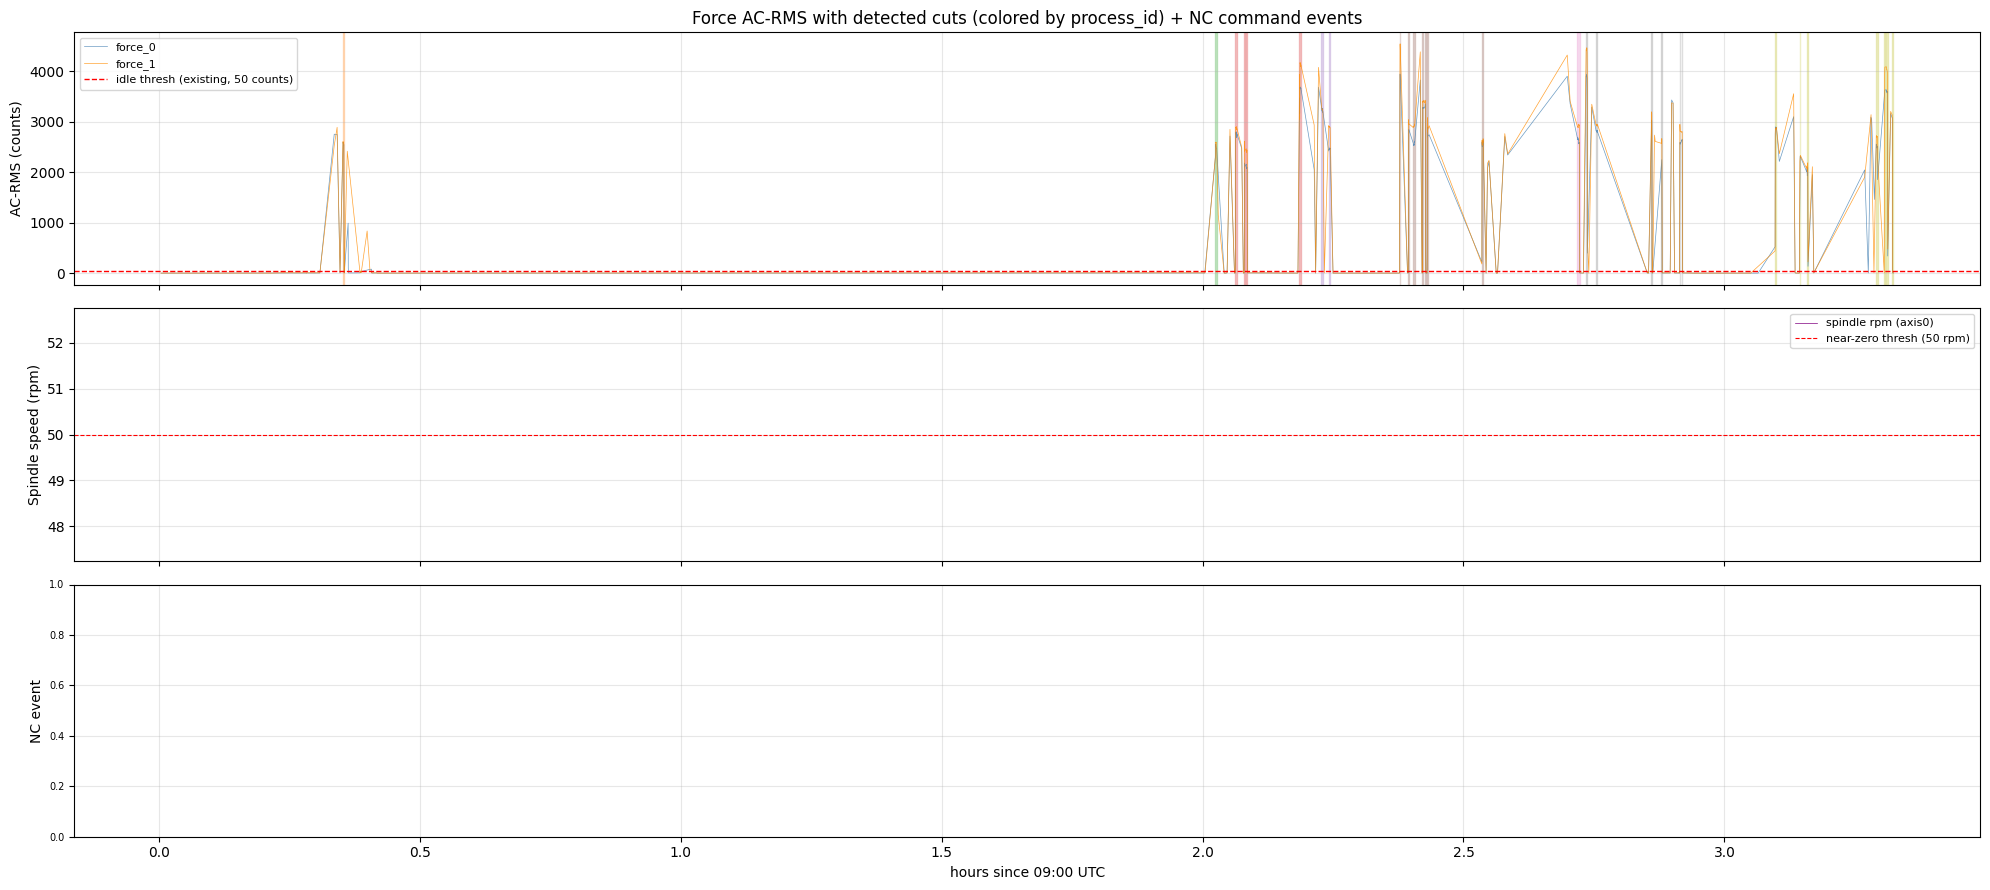

saved lev008_ALU_y_nc_events_qa.png


In [13]:
def load_ac_rms(fname):
    df = pd.read_parquet(OLD_DIR / fname)
    sc = sorted([c for c in df.columns if c.startswith("s") and c[1:].isdigit()])
    df = df.sort_values("time").reset_index(drop=True)
    d  = df[sc].to_numpy(dtype=np.float64)
    ac = np.sqrt(np.mean((d - d.mean(axis=1, keepdims=True))**2, axis=1))
    return df[["time"]].assign(ac_rms=ac)


b0 = load_ac_rms("force_0_lev008_raw.parquet")
b1 = load_ac_rms("force_1_lev008_raw.parquet")

t_ref = EXPT_START
b0e = b0[b0.time >= t_ref].reset_index(drop=True)
b1e = b1[b1.time >= t_ref].reset_index(drop=True)
me  = mdf[mdf.sample_time >= t_ref].reset_index(drop=True)
ee  = events_df[events_df.timestamp >= t_ref].reset_index(drop=True)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 9), sharex=True)

for bdf, col, lbl in [(b0e, "steelblue", "force_0"), (b1e, "darkorange", "force_1")]:
    h = (bdf["time"].dt.round("1s") - t_ref).dt.total_seconds() / 3600
    ax1.plot(h, bdf["ac_rms"].values, lw=0.5, color=col, label=lbl, alpha=0.8)
ax1.axhline(50.0, color="red", ls="--", lw=1, label="idle thresh (existing, 50 counts)")
colors = plt.cm.tab10.colors
for _, row in cuts_tagged.iterrows():
    ts = (row.cut_start - t_ref).total_seconds() / 3600
    te = (row.cut_end - t_ref).total_seconds() / 3600
    pid = int(row.process_id)
    c = colors[pid % 10] if pid >= 0 else "gray"
    ax1.axvspan(ts, te, alpha=0.25, color=c)
ax1.set_ylabel("AC-RMS (counts)")
ax1.set_title("Force AC-RMS with detected cuts (colored by process_id) + NC command events")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

h_spindle = (me["sample_time"] - t_ref).dt.total_seconds() / 3600
ax2.plot(h_spindle, me["axis0_speedorfeedact"], lw=0.5, color="purple", label="spindle rpm (axis0)")
ax2.axhline(SPINDLE_RPM_THRESH, color="red", ls="--", lw=0.8, label=f"near-zero thresh ({SPINDLE_RPM_THRESH:.0f} rpm)")
ax2.set_ylabel("Spindle speed (rpm)")
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, alpha=0.3)

marker_style = {
    "nc_start": ("^", "green"), "nc_stop": ("v", "red"),
    "wait_begin": ("s", "orange"), "wait_end": ("s", "gold"),
    "spindle_near_zero_begin": ("o", "purple"), "spindle_near_zero_end": ("o", "violet"),
    "rapid_candidate_begin": ("x", "black"), "rapid_candidate_end": ("x", "gray"),
    "program_run_begin": (">", "darkgreen"), "program_run_end": ("<", "darkred"),
    "program_stopped_begin": ("s", "brown"), "program_stopped_end": ("s", "tan"),
}
for etype, grp in ee.groupby("event_type"):
    marker, color = marker_style.get(etype, ("o", "black"))
    h = (grp["timestamp"] - t_ref).dt.total_seconds() / 3600
    ax3.scatter(h, [etype] * len(grp), marker=marker, color=color, s=25)
ax3.set_ylabel("NC event")
ax3.set_xlabel("hours since 09:00 UTC")
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lev008_ALU_y_nc_events_qa.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved lev008_ALU_y_nc_events_qa.png")

## 7 - Verification

In [14]:
back_events = pd.read_parquet(OUTPUT_DIR / "nc_command_log_lev008_ALU_y.parquet")
back_summary = pd.read_parquet(OUTPUT_DIR / "lev008_ALU_y_cut_summary_tagged.parquet")

print("=== VERIFICATION ===")
print(f"nc_command_log rows={len(back_events)}, event types={back_events.event_type.nunique()}")
print(f"monotonic timestamps: {back_events['timestamp'].is_monotonic_increasing}")
print(f"cut_summary_tagged rows={len(back_summary)}, cols={back_summary.shape[1]}")
print(f"cuts with >=1 nearby NC event: {(back_summary['nc_events'].str.len() > 0).sum()} / {len(back_summary)}")
print()
print("Event type counts:")
print(back_events["event_type"].value_counts().to_string())

=== VERIFICATION ===
nc_command_log rows=16470, event types=9
monotonic timestamps: True
cut_summary_tagged rows=29, cols=30
cuts with >=1 nearby NC event: 0 / 29

Event type counts:
event_type
rapid_candidate_begin      3436
rapid_candidate_end        3435
spindle_near_zero_end      1679
spindle_near_zero_begin    1678
program_run_begin          1578
program_run_end            1577
program_stopped_end        1497
program_stopped_begin      1496
nc_start                     94
